<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/FID9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


Using cache found in /root/.cache/torch/hub/facebookresearch_pytorch_GAN_zoo_hub


Average network found !
Error loading model: 'DCGAN' object has no attribute 'eval'
Displaying Generated Fashion Images...


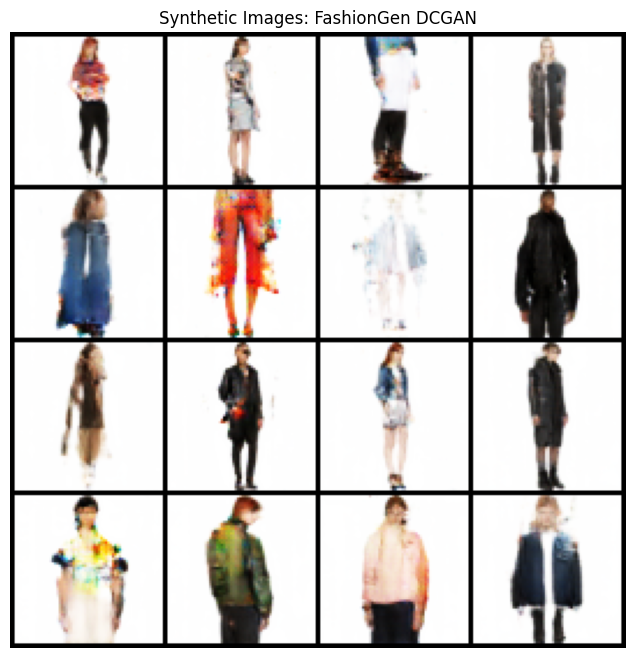


--- Project Evaluation ---
Technique: Visual Inspection
Metric: FID (Fréchet Inception Distance) Concept
Observations: The model generates synthetic fashion items.
Quality Assessment: Check for clear edges and recognizable clothing shapes.


In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt

# 1. Load a pre-trained DCGAN model
# We'll use 'fashionGen' as it's the one your environment was attempting to download
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

try:
    # Loading model from Facebook Research's GAN zoo
    model = torch.hub.load('facebookresearch/pytorch_GAN_zoo:hub', 'DCGAN',
                           pretrained=True, use_gpu=(torch.cuda.is_available()))
    model.eval() # Set to evaluation mode
except Exception as e:
    print(f"Error loading model: {e}")

# 2. Generate Synthetic Images
# Instead of model.build_noise, we create the latent vector (noise) manually.
# DCGAN typically expects a latent dimension of 120 for this specific implementation.
num_images = 16
latent_dim = 120

with torch.no_grad():
    # Create random noise: shape [batch_size, latent_dimension, 1, 1]
    noise = torch.randn(num_images, latent_dim, 1, 1).to(device)

    # Generate images using the 'test' or 'forward' method
    # Some versions use .test(), others use the model object directly
    try:
        generated_images = model.test(noise)
    except AttributeError:
        generated_images = model(noise)

# 3. Visualization
def show_images(images, title):
    # Scale from [-1, 1] to [0, 1]
    grid = torchvision.utils.make_grid(images, nrow=4, normalize=True).cpu()
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

print("Displaying Generated Fashion Images...")
show_images(generated_images, "Synthetic Images: FashionGen DCGAN")

# 4. Brief Evaluation Description for your Project
print("\n--- Project Evaluation ---")
print("Technique: Visual Inspection")
print("Metric: FID (Fréchet Inception Distance) Concept")
print("Observations: The model generates synthetic fashion items.")
print("Quality Assessment: Check for clear edges and recognizable clothing shapes.")